In [53]:
%load_ext autoreload
%autoreload 2
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from get_ddf import get_ddf_df
from data_handling import *
import statsmodels.api as sm
from scipy.stats import gaussian_kde as kde
import sys 
from scipy.optimize import minimize
sys.path.append('/trace/home/cvwilson/research/PEBSI/shop/plotting/')
from plotting_fxns import *

import socket
if 'trace' in socket.gethostname():
    base_fp = '/trace/group/rounce/cvwilson/Output/ddf/'
    home_fp = '/trace/home/cvwilson/research/'
else:
    base_fp = 'C:/Users/cvw30/Research/Output/'
    home_fp = 'C:/Users/cvw30/Research/'

colors = ['#63c4c7','#fcc02e','#4D559C','#60C252','#BF1F6A',
              '#F77808','#298282','#999999','#FF89B0','#427801']
coord_dict = {'wolverine':'60.5_-148.7',
                'kahiltna':'63.0_-151.2',
                'kennicott':'61.5_-143.1',
                'taku':'58.5_-134.3',
                'lemon_creek':'58.5_-134.3',
                'gulkana':'63.5_-145.6'}
site_dict = {
    'kahiltna':['K17b','K14k','K53'], # KAHILTNA     'KPS',
    'kennicott':['GTH','KC31','GTL'], # KENNICOTT
    'gulkana':['AU','B','D'], # GULKANA
    'wolverine':['N','B','EC'], # WOLVERINE
    'lemon_creek':['B','C','D'], # LEMON CREEK
    'taku':['MG1','NWB1','TKG3'], # TAKU
}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


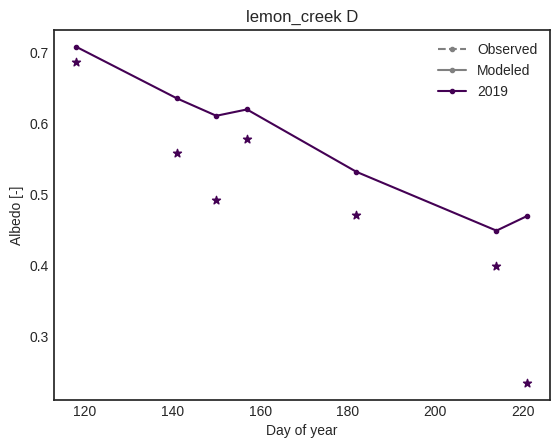

(<Figure size 500x340 with 4 Axes>, array([<Axes: >, <Axes: >], dtype=object))

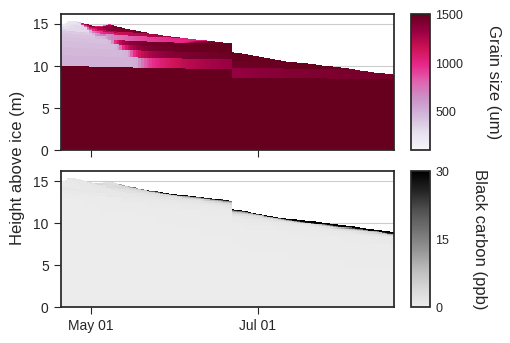

In [83]:
glacier, site = 'lemon_creek','D'
dates = pd.date_range('2019-04-20','2019-08-20')
ds = xr.open_dataset(base_fp + f'{glacier}{site}_2026_03_05_base_0.nc')
mb = MassBalance(glacier, site)
albedo = Albedo(glacier, site, use='L8')

# mb.get_model_mb(ds)
albedo.get_model_albedo(ds)
# mb.plot_mb()
albedo.plot_timeseries()
visualize_layers(ds, dates, ['layergrainsize','layerBC'])
# plt.plot(ds.time, ds.layergrainsize.isel(layer=0))

In [15]:
coords = coord_dict['gulkana']
ds_bcd = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/BCDP002_{coords}.nc')
ds_bcw = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/BCWT002_{coords}.nc')
ds_bc = ds_bcd['BCDP002'] + ds_bcw['BCWT002']

by_bc = {}
fpd = base_fp + '../02_26_gulkana_D_1/'
nc_files = [fpd + f for f in os.listdir(fpd) if f.endswith('.nc')]

for fn in nc_files:
    ds = xr.open_dataset(fn)
    if ds.attrs['ksp_BC'] == '1':
        by_bc[ds.attrs['frac_BC']] = get_ddf_df(ds, ds_bc, n_rolling_pdds = 1)

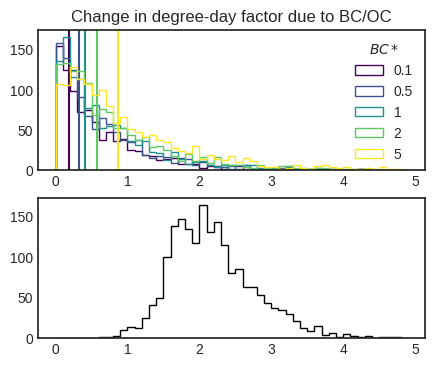

In [72]:
f_snow = by_bc['0']['ddf']
fig, (ax, ax2) = plt.subplots(2, figsize=(5, 4))
bins = np.arange(0, 5, 0.1)
cmap = plt.get_cmap('viridis')
norm = mpl.colors.Normalize(vmin=0, vmax=4)
for f, frac_BC in enumerate(['0.1','0.5','1','2','5']):
    df = by_bc[frac_BC]
    fBC = (df['melt'] - f_snow*df['pdds_1d_rolling']) / (df['pdds_1d_rolling'])
    ax.hist(fBC.values, bins=bins, histtype='step', edgecolor=cmap(norm(f)), label=frac_BC)
    ax.axvline(np.nanmean(fBC.values),color=cmap(norm(f)))
ax.legend(title='$BC*$')
ax.set_title('Change in degree-day factor due to BC/OC')
ax2.hist(f_snow, histtype='step', edgecolor='k', bins=np.arange(0,5, 0.1))
plt.show()

In [ ]:
def find_kp(k, ds, bmeas, starts, ends):
    acc_mod = []
    add_mod = []
    for start, end in zip(starts, ends):
        acc_mod.append(ds.sel(time=slice(start, end)).accum.sum().values)
        refreeze = ds.sel(time=slice(start, end)).refreeze.sum().values
        melt = -1*ds.sel(time=slice(start, end)).melt.sum().values
        add_mod.append(refreeze + melt)
    acc_mod = np.array(acc_mod)
    add_mod = np.array(add_mod)
    
    objective = np.mean(np.abs((acc_mod * k + add_mod) - np.array(bmeas)))
    return objective

all_albedo = {'mod':[], 'meas':[]}
for glacier in site_dict:
    site_fn = f'../data/by_glacier/{glacier}/site_constants.csv'
    site_df = pd.read_csv(site_fn, index_col=0)
    if 'kp' not in site_df.columns:
        site_df['kp'] = site_df['lat'].copy() * np.nan

    for site in site_dict[glacier]:
        mb = MassBalance(glacier, site, use='benchmark')
        ds = xr.open_dataset(base_fp + f'{glacier}{site}_2026_02_26_base_0.nc')

        # mb.get_model_mb(ds)
        # mb.plot_mb()
        # albedo = Albedo(glacier, site)
        # albedo.get_model_albedo(ds)
        # albedo.plot_timeseries()
        # for mod, meas in zip(albedo.mod, albedo.meas):
        #     all_albedo['mod'].append(mod)
        #     all_albedo['meas'].append(meas)

        if mb.dataset == 'seasonal':
            mb.get_model_mb(ds)
            starts = mb.period_starts[mb.idx_winter]
            ends = mb.period_ends[mb.idx_winter]
            bw_meas = mb.meas[mb.idx_winter]
            
            result = minimize(find_kp,1,
                                      method='L-BFGS-B',bounds=((0, 5),),
                                      args=(ds, bw_meas, starts, ends))
            kp = result.x[0]
            site_df.loc[site, 'kp'] = kp

            bw_mod = []
            bw_mod_kp = []
            for start, end in zip(starts, ends):
                acc = ds.sel(time=slice(start, end)).accum.sum().values
                refreeze = ds.sel(time=slice(start, end)).refreeze.sum().values
                melt = -1*ds.sel(time=slice(start, end)).melt.sum().values
                bw_mod.append(acc + refreeze + melt)
                bw_mod_kp.append(acc*kp + refreeze + melt)

            print(glacier, site, kp)
            # plt.figure(figsize=(3,3))
            # plt.plot(pd.to_datetime(ends).year, bw_meas, 'k', label='Measured')
            # plt.plot(pd.to_datetime(ends).year, bw_mod, 'k--', label='Modeled')
            # plt.plot(pd.to_datetime(ends).year, bw_mod_kp, 'r', label=f'Model with kp {kp:.3f}')
            # plt.title(glacier+' '+site)
            # plt.legend()
            # plt.show()
    # site_df.to_csv(site_fn)

kahiltna K17b 0.7023414238186757
kahiltna K53 1.7068888637879764
kennicott GTH 1.6634793010179634
kennicott KC31 1.130154191842188
kennicott GTL 1.0094549347163355
gulkana AU 2.0588026401017103
gulkana B 2.710018518732716
gulkana D 3.1900623202381246
wolverine N 0.9877200957743191
wolverine B 1.1477651719827946
wolverine EC 1.981469475081177
lemon_creek B 1.4230809067903878
lemon_creek C 1.5168359512504206
lemon_creek D 1.5903339881579404


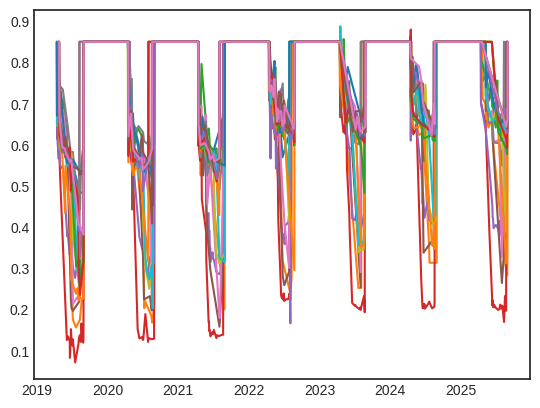

In [56]:
for glacier in site_dict:
    for site in site_dict[glacier]:
        albedo = Albedo(glacier, site)
        if len(np.where(~np.isnan(albedo.data))[0]) < 10:
            continue

        df_all = None
        for year in np.unique(pd.to_datetime(albedo.time).year):
            idx_year = np.where(pd.to_datetime(albedo.time).year == year)[0]
            df = pd.DataFrame({'albedo': albedo.data.flatten()[idx_year]}, 
                          index=pd.to_datetime(albedo.time)[idx_year])
            df.index = pd.to_datetime(df.index).normalize()
            df = df.reindex(pd.date_range(df.index.min(), df.index.max(), freq='D'))
            df = df.interpolate(method='time')

            df.index = pd.DatetimeIndex(df.index)
            
            df.loc[df.index.min() - pd.Timedelta(days=1),'albedo'] = 0.85
            df.loc[df.index.max() + pd.Timedelta(days=1),'albedo'] = 0.85
            df = df.sort_index()

            if df_all is None:
                df_all = df 
            else:
                df_all = pd.concat([df_all, df])

        df_all = df_all.reindex(pd.date_range(df_all.index[0], df_all.index[-1]))
        df_all = df_all.interpolate(method='time')
        df_hourly = df.resample('h').ffill().sort_index()
        plt.plot(df_all.index, df_all['albedo'])
        # print(df_all)
        df_all.to_csv(home_fp + f'climate_data/AWS/albedo/{glacier}{site}_S2albedo.csv')
        # assert 1==0

/tmp/ipykernel_127354/1523039872.py:11: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset(fn)


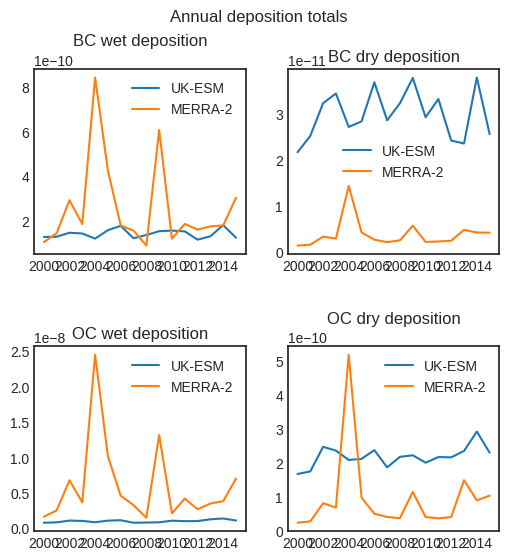

In [2]:
climate_fp = '/trace/group/rounce/cvwilson/climate_data/UKESM/'

deptype = 'wet'
species = 'BC'

fig, axes = plt.subplots(2, 2, figsize=(6, 6), gridspec_kw={'hspace':0.5, 'wspace':0.2})

for axrow, species in zip(axes, ['BC','OC']):
    for ax, deptype in zip(axrow, ['wet','dry']):
        fn = climate_fp + f'dr401_GFED/sum_{species.lower()}_{deptype}deposition_kgm-2s-1.nc'
        ds = xr.open_dataset(fn)
        for var in list(ds.variables):
            if 'tendency' in var:
                vuse = var 

        ds = ds[vuse].sel(latitude=63.259091,longitude=-145.428586,method='nearest')
        ds = ds.sel(time=slice('2000-01-01','2025-01-01'))

        depmerra = 'WT' if deptype == 'wet' else 'DP'
        dsm = xr.open_dataarray(f'../../climate_data/MERRA2/63.5_-145.6/{species}{depmerra}002_63.5_-145.6.nc')
        dsm = dsm.sel(time=ds.time.values + pd.Timedelta(minutes=30))

        resample = 'YS'
        ds = ds.resample(time=resample).sum()
        dsm = dsm.resample(time=resample).sum()

        ax.plot(ds.time.values, ds.values, label='UK-ESM')
        ax.plot(dsm.time.values, dsm.values, label='MERRA-2')
        ax.legend()
        max_val = np.max([ds.values, dsm.values])
        # ax.plot([0, max_val], [0, max_val], 'k--')
        # ax.scatter(dsm.values, ds.values)
        ax.set_title(f'{species} {deptype} deposition')
fig.suptitle('Annual deposition totals')
# fig.supxlabel('MERRA-2')
# fig.supylabel('UK-ESM')
plt.show()

In [76]:
site_dict = {
    'kahiltna':['K17b','K53'], # KAHILTNA     'KPS',
    'kennicott':['KC31','GTL'], # KENNICOTT 'GTH',
    'gulkana':['AU'], # GULKANA  ,'B','D'
    'wolverine':['N','B','EC'], # WOLVERINE
    'lemon_creek':['B','C'], # LEMON CREEK 'D'
    'taku':['NWB1',], # TAKU    'MG1','TKG3'
}

all_albedo = {'mod':[], 'meas':[], 'time':[]}
for glacier in site_dict:
    for site in site_dict[glacier]:
        albedo = Albedo(glacier, site, use='both')
        ds = xr.open_dataset(base_fp + glacier + site +'_2026_03_05_base_0.nc')
        albedo.get_model_albedo(ds)
        # albedo.plot_timeseries()

        for mod, meas, date in zip(albedo.mod, albedo.meas, albedo.time):
            all_albedo['mod'].append(mod)
            all_albedo['meas'].append(meas)
            all_albedo['time'].append(date)

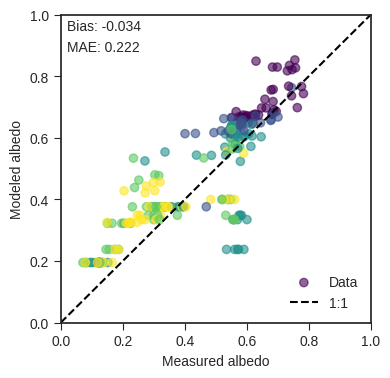

In [77]:
fig, ax = plt.subplots(figsize=(4, 4))
cmap = plt.get_cmap('viridis')
norm = mpl.colors.Normalize(vmin=4, vmax=8)
markers = {'wolverine':'*', 'gulkana':'o', 'kahiltna':'3', 'kennicott':'^','lemon_creek':'.','taku':'1'}
# for glacier in site_dict:
#     for site in site_dict[glacier]:
#         albedo = Albedo(glacier, site)
#         ds = xr.open_dataset(base_fp + glacier + site +'_2026_03_04_base_3.nc')
#         albedo.get_model_albedo(ds)
#         ax.scatter(albedo.meas, albedo.mod, alpha=0.6, label=glacier, c=cmap(norm(pd.to_datetime(albedo.time).month)), marker=markers[glacier])
ax.scatter(all_albedo['meas'], all_albedo['mod'], alpha=0.6, label='Data', c=cmap(norm(pd.to_datetime(all_albedo['time']).month)))
ax.plot([0,1],[0,1],'k--',label='1:1')

bias = np.nanmean(np.array(all_albedo['meas']) - np.array(all_albedo['mod']))
mae = np.nanmean(np.abs(np.array(all_albedo['meas']) - np.array(all_albedo['mod'])))
ax.text(0.02, 0.95, f'Bias: {bias:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.88, f'MAE: {mae:.3f}', transform=ax.transAxes)

ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.tick_params(length=5)
ax.set_ylabel('Modeled albedo')
ax.set_xlabel('Measured albedo')
plt.show()

(<Figure size 500x510 with 6 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >], dtype=object))

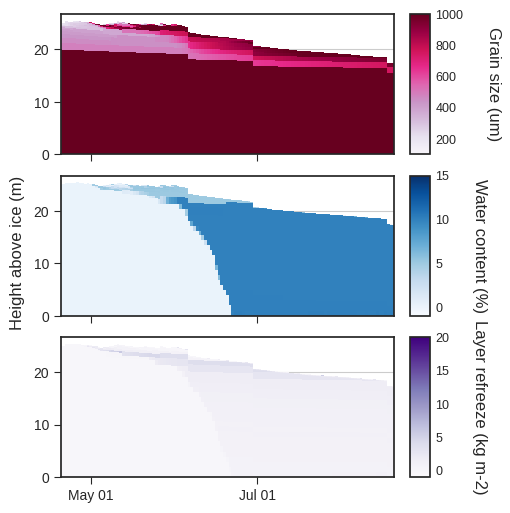

In [60]:
ds = xr.open_dataset(base_fp + 'wolverineEC_2026_03_04_base_3.nc')
visualize_layers(ds, pd.date_range('2019-04-20','2019-08-20'), ['layergrainsize','layerwater','layerrefreeze'])
# plt.plot(ds.time, ds.layergrainsize.isel(layer=0))
# plt.show()
# plt.plot(ds.time, ds.layerBC.isel(layer=0))
# ds = ds.where(ds.layertype.min(dim='layer') == 0, drop=True)
# ds = ds.resample(time='d').min()
# plt.scatter(ds.albedo, ds.layerBC.isel(layer=0))

In [25]:
site_dict = {
    'kahiltna':['K17b','K53'], # KAHILTNA     'KPS',
    'kennicott':['KC31','GTL'], # KENNICOTT 'GTH',
    'gulkana':['AU'], # GULKANA  ,'B','D'
    'wolverine':['N','B','EC'], # WOLVERINE
    'lemon_creek':['B','C','D'], # LEMON CREEK
    'taku':['NWB1',], # TAKU    'MG1','TKG3'
}
all_df = None
for glacier in site_dict:
    coords = coord_dict[glacier]
    ds_bcd = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/BCDP002_{coords}.nc')
    ds_bcw = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/BCWT002_{coords}.nc')
    ds_bc = ds_bcd['BCDP002'] + ds_bcw['BCWT002']

    dsu = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/U2M_{coords}.nc')['U2M']
    dsv = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/V2M_{coords}.nc')['V2M']
    wind = np.sqrt(np.square(dsu.values) + np.square(dsv.values))
    dsv.values = wind 
    all_wind = dsv.resample(time='d').mean()
    # glac_qms = {'taku':'lemon_creek','kennicott':'gulkana'}
    # glac_qm = glac_qms[glacier] if glacier in glac_qms else glacier
    # df_qm = pd.read_csv(f'../data/bias_adjustment/quantile_mapping_{glac_qm}_wind.csv')
    # adj = np.interp(values, df_qm['sorted'], df_qm['mapping'])
    # dsv.values = adj 
    # wind = dsv.resample(time='d').mean()

    for site in site_dict[glacier]:
        # albedo = Albedo(glacier, site)
        ds = xr.open_dataset(base_fp + glacier + site +'_2026_03_04_base_1.nc')
        # albedo.get_model_albedo(ds)
        # albedo.plot_timeseries()
        out = base_fp+f'{glacier}{site}_df.csv'
        df = get_ddf_df(ds, ds_bc,  n_rolling_bc=5, n_rolling_pdds=1, savefig=True) # output_fn=out, plot_corr=True,
        df['glacier'] = [glacier] * len(df.index)
        df['glaciersite'] = [glacier + site] * len(df.index)
        df['wind'] = all_wind.sel(time=pd.to_datetime(df.index)).values 
        if all_df is not None:
            all_df = pd.concat([all_df, df])
        else:
            all_df = df

/trace/home/cvwilson/miniconda3/envs/eb_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1598: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


In [26]:
acc_sites = []
for glacier in site_dict:
    for site in site_dict[glacier]:
        data = MassBalance(glacier, site, use='benchmark annual')
        if np.mean(data.data) > 0:
            acc_sites.append(glacier+site)

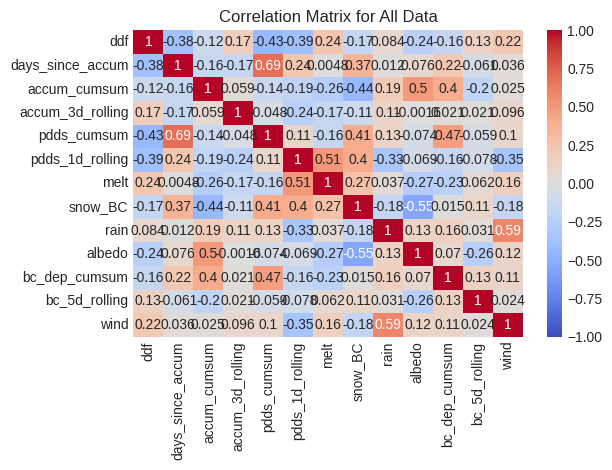

In [27]:
all_df = all_df.loc[all_df['glaciersite'].isin(acc_sites)]

corr = all_df.drop(columns=['glacier','glaciersite']).corr()
plt.figure()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title(f'Correlation Matrix for All Data')
plt.tight_layout()
plt.show()

/tmp/ipykernel_601064/2714451440.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


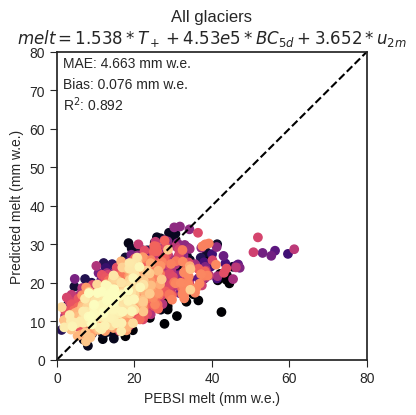

/tmp/ipykernel_601064/2714451440.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


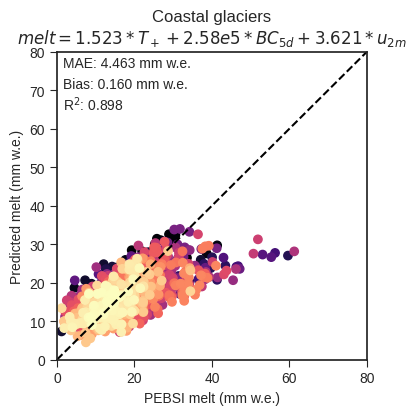

/tmp/ipykernel_601064/2714451440.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


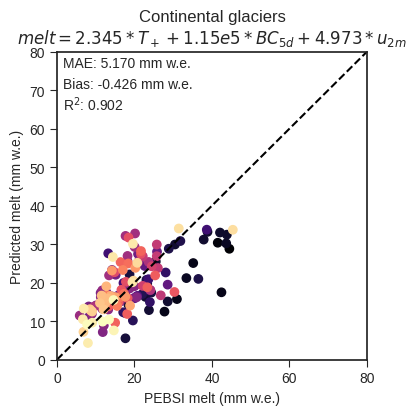

In [34]:
all_groups = {
          'all':['gulkana','wolverine','taku','kennicott','kahiltna','lemon_creek'], 
          'coastal':['wolverine','taku','lemon_creek'],
          'continental':['gulkana','kennicott','kahiltna'],
          }
for group in all_groups:
    glac_df = all_df.loc[all_df['glacier'].isin(all_groups[group])]
    X = glac_df[['pdds_1d_rolling', 'bc_5d_rolling', 'wind']] # 
    y = glac_df['melt']

    model = sm.OLS(y, X).fit()

    ddf = model.params['pdds_1d_rolling']
    bcf = model.params['bc_5d_rolling']
    wf = model.params['wind']
    melt_predicted = glac_df['pdds_1d_rolling'] * ddf + glac_df['bc_5d_rolling'] * bcf + glac_df['wind']*wf
    melt_actual = glac_df['melt']

    x = melt_actual.values
    y = melt_predicted.values
    xy = np.vstack([x, y])
    z = kde(xy)(xy)
    idx = z.argsort()
    x, y, z = x[idx], y[idx], z[idx]

    fig, ax = plt.subplots(figsize=(4, 4))
    ax.scatter(melt_actual, melt_predicted, c=z, cmap='magma')
    ax.plot([0,80],[0,80],'k--')
    ax.legend()
    ax.tick_params(length=5)
    ax.set_xlim(0, 80)
    ax.set_ylim(0, 80)
    ax.set_xlabel('PEBSI melt (mm w.e.)')
    ax.set_ylabel('Predicted melt (mm w.e.)')
    ax.set_title(f'{group.capitalize()} glaciers\n$melt={ddf:.3f}*T_++{bcf:.2e}*'.replace('e+0','e')+r'BC_{5d}'+f'+{wf:.3f}*'+r'u_{2m}$')

    mae = np.nanmean(np.abs(melt_predicted - melt_actual))
    bias = np.nanmean(melt_predicted - melt_actual)
    r2 = model.rsquared
    ax.text(0.02, 0.95, f'MAE: {mae:.3f} mm w.e.', transform=ax.transAxes)
    ax.text(0.02, 0.88, f'Bias: {bias:.3f} mm w.e.', transform=ax.transAxes)
    ax.text(0.02, 0.81, f'R$^2$: {r2:.3f}', transform=ax.transAxes)

    plt.show()


In [35]:
print(all_df.loc[all_df['melt'] < 60])

                 ddf  days_since_accum  accum_cumsum  accum_3d_rolling  \
time                                                                     
2019-06-28  5.154438               7.0    244.539734          0.000000   
2019-06-29  4.606316               8.0    244.539734          0.000000   
2019-06-30  4.389071               9.0    244.539734          0.000000   
2019-07-01  4.741626               0.0    244.923468          0.383734   
2019-07-02  4.981317               1.0    244.923468          0.383734   
...              ...               ...           ...               ...   
2025-08-15  1.649880               9.0   5425.550850          0.000000   
2025-08-16  1.442523              10.0   5425.550850          0.000000   
2025-08-17  1.419900              11.0   5425.550850          0.000000   
2025-08-18  1.435307               0.0   5425.874201          0.323351   
2025-08-19  1.666208               1.0   5425.874201          0.323351   

            pdds_cumsum  pdds_1d_roll

In [ ]:
cats = all_df['glaciersite'].astype('category').cat.categories
codes = all_df['glaciersite'].astype('category').cat.codes

# pick a colormap with enough distinct colors
base_cmap = plt.cm.get_cmap('Dark2', len(cats))
cmap = mpl.colors.ListedColormap(base_cmap.colors)

plt.scatter(
    all_df['pdds_3d_rolling'],
    all_df['ddf'],
    c=codes,
    cmap=cmap
)

# legend
for code, name in enumerate(cats):
    plt.scatter([], [], color=cmap(code), label=name)

plt.legend(title='Glacier')
plt.show()


In [ ]:
glacier = 'gulkana'
site = 'B'
data = SnowMelt(glacier, site)
ds = xr.open_dataset(base_fp + f'{glacier}{site}_2026_02_03_base_long_0.nc')
data.get_model_snow(ds)
error = data.model_error_metric(data.mod_melt, data.sar_melt['med'], data.time, transition_type='onset')
print('Melt onset MAE:',error,'days')

error = data.model_error_metric(data.mod_snow, data.sar_snow['med'], data.time, transition_type='offset')
print('Snowline MAE:',error,'days')

In [ ]:
data.plot_snow_bool()
data.plot_melt_bool()

In [ ]:
#comparing quantile mapping approaches
# ds_lemon = xr.open_dataset(base_fp + 'takuTKG3_2026_02_15_base_qmlemonkp2_0.nc')
# ds_gulk = xr.open_dataset(base_fp + 'takuTKG3_2026_02_12_base_qmallkp2_0.nc')

coords = '58.5_-134.3'
for var in ['wind','temp','rh']:
    if var == 'wind':
        dsu = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/U2M_{coords}.nc')['U2M']
        dsv = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/V2M_{coords}.nc')['V2M']
        ds_clim = np.sqrt(np.square(dsu.values) + np.square(dsv.values))
    elif var == 'rh':
        ds_clim = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/RH2M_{coords}.nc')['RH2M'].values
    elif var == 'temp':
        ds_clim = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/T2M_{coords}.nc')['T2M'].values - 273.15
    varn = var if var != 'temp' else 'temp_0'
    df_gulk = pd.read_csv(f'../data/bias_adjustment/quantile_mapping_gulkana_{varn}.csv')
    df_lem = pd.read_csv(f'../data/bias_adjustment/quantile_mapping_lemon_creek_{varn}.csv')
        
    # interpolate values according to quantile mapping
    values = ds_clim
    adj_gulk = np.interp(values, df_gulk['sorted'], df_gulk['mapping'])
    adj_lem = np.interp(values, df_lem['sorted'], df_lem['mapping'])

    # plt.scatter(adj_gulk, adj_lem, s=5, alpha=0.5)
    plt.scatter(values, adj_lem, s=5, alpha=0.5,label='lemon')
    plt.scatter(values, adj_gulk, s=5, alpha=0.5,label='gulkana')
    minn = np.min([adj_gulk, adj_lem])
    maxx = np.max([adj_gulk, adj_lem])
    plt.ylabel('Original MERRA-2') # Lemon Creek adjusted')
    plt.xlabel('Adjusted') # Gulkana adjusted')
    plt.plot([minn,maxx],[minn,maxx],'k--')
    plt.legend()
    plt.title(var)
    plt.show()

In [ ]:
ds = xr.open_dataset('../climate_data/MERRA2/BCDP002/MERRA2_BCDP002_gulkana_alltime.nc')
ds2 = xr.open_dataset('../climate_data/MERRA2/BCWT002/MERRA2_BCWT002_gulkana_alltime.nc')
ds['BCDP002'] = ds['BCDP002'] + ds2['BCWT002']
# define time variables
months = ds['time'].dt.month
days = ds['time'].dt.day
# create time mask from apr 1 to sep 30 (inclusive)
mask = ((months > 3) & (months < 10))
ds_season = ds.where(mask, drop=True)
annual_sums = ds_season.groupby('time.year').sum()
plt.plot(annual_sums.year, annual_sums['BCDP002'].values)
plt.axhline(np.quantile(annual_sums['BCDP002'].values, 0.90), c='r')

threshold = np.quantile(annual_sums['BCDP002'].values, 0.90)
base_idx = np.where(annual_sums['BCDP002'].values <= threshold)[0]
fire_idx = np.where(annual_sums['BCDP002'].values > threshold)[0]
plt.scatter(annual_sums.year.values[fire_idx], annual_sums['BCDP002'].values[fire_idx], color='red', marker='*')
plt.show()

fire_years = annual_sums.year.values[fire_idx]
base_years = annual_sums.year.values[base_idx]

In [73]:
# acceptable = {
#     'gulkana':{'AU':'gulkanaAU_2026_02_03_base_long_0.nc',
#                'B':'gulkanaB_2026_02_03_base_long_0.nc',
#                'D':'gulkanaD_2026_02_03_base_long_0.nc',
#                },
#     'wolverine':{'N':'wolverineN_2026_02_12_base_qmwindkp1_0.nc',
#                  'B':'wolverineB_2026_02_17_base_qmwolvkp2_0.nc',
#                  'EC':'wolverineEC_2026_02_12_base_qmwindkp1_0.nc',
#                  },
#     'kahiltna':{'K17b':'kahiltnaK17b_2026_02_13_base_qmwindkp0.5_0.nc',
#                  'K53':'kahiltnaK53_2026_02_12_base_qmwindkp2_0.nc',
#                  },
#     'kennicott':{'GTH':'kennicottGTH_2026_02_12_base_qmwindkp1_0.nc',
#                  'GTL':'kennicottGTL_2026_02_13_base_qmwindkp0.5_0.nc',
#                  },
#     'taku':{'MG1':'takuMG1_2026_02_12_base_qmwindkp1_0.nc',
#             'NWB1':'takuNWB1_2026_02_12_base_qmwindkp1_0.nc',
#             }
# }

# all_df = None
# for glacier in acceptable:
#     coords = coord_dict[glacier]
#     ds_bcd = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/BCDP002_{coords}.nc')
#     ds_bcw = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/BCWT002_{coords}.nc')
#     ds_bc = ds_bcd['BCDP002'] + ds_bcw['BCWT002']
#     for site in acceptable[glacier]:
#         ds = xr.open_dataset(base_fp + glacier+site+'_2026_02_25_base_0.nc') # acceptable[glacier][site])
#         out = base_fp+f'{glacier}{site}_df.csv'
#         df = get_ddf_df(ds, ds_bc, plot_corr=True, n_rolling_bc=5, n_rolling_pdds=3, output_fn=out, savefig=True)
#         df['glacier'] = [glacier] * len(df.index)
#         df['glaciersite'] = [glacier + site] * len(df.index)
#         if all_df is not None:
#             all_df = pd.concat([all_df, df])
#         else:
#             all_df = df